In [13]:
##Predicting 2011-2020 Global Monthly Average Temperature Using Historical Data from 1970-2019
##Only Using Data from Stations with at least 45 years of data

In [16]:
###########
# STEP 1: Load Pyspark functions and utilities
###########

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, year, month, avg, countDistinct, regexp_replace,
    round, when, create_map, lit, row_number
)
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.window import Window
from itertools import chain

###########
# STEP 2: Loading and Cleaning Data
###########

spark = SparkSession.builder.appName("GSOD Decade Temp Prediction").getOrCreate()
df = spark.read.parquet("/home/jovyan/Project/gsod_parquet_enriched")

# Add year and month
df = df.withColumn("year", year("DATE")).withColumn("month", month("DATE"))

###########
# STEP 3: Clean and filter data
###########

# Drop rows with missing or unrealistic values
df_clean = df.filter(
    (col("TEMP").isNotNull()) & 
    (col("LATITUDE").isNotNull()) & (col("LONGITUDE").isNotNull()) &
    (col("ELEVATION").isNotNull()) & 
    (col("PRCP").isNotNull()) & (col("PRCP") < 99.99) &
    (col("SLP").isNotNull()) & (col("SLP") < 9999) &
    (col("WDSP").isNotNull()) & (col("WDSP") < 999.9)
)

# Keep stations with at least 45 years of data
df_recent = df_clean.filter((col("year") >= 1970) & (col("year") <= 2023))
station_counts = df_recent.groupBy("STATION").agg(countDistinct("year").alias("year_count"))
valid_stations = station_counts.filter(col("year_count") >= 45)
df_filtered = df_recent.join(valid_stations, on="STATION", how="inner")

###########
# STEP 4: Aggregate to monthly average per station
###########

df_monthly = df_filtered.groupBy(
    "STATION", "LATITUDE", "LONGITUDE", "ELEVATION", "year", "month"
).agg(
    avg("TEMP").alias("AVG_TEMP"),
    avg("PRCP").alias("PRCP"),
    avg("SLP").alias("SLP"),
    avg("WDSP").alias("WDSP")
)

# Drop nulls from modeling fields
df_monthly = df_monthly.dropna(subset=[
    "LATITUDE", "LONGITUDE", "ELEVATION", "year", "month",
    "AVG_TEMP", "PRCP", "SLP", "WDSP"
])

###########
# STEP 5: Feature engineering
###########

assembler = VectorAssembler(
    inputCols=["LATITUDE", "LONGITUDE", "ELEVATION", "year", "month", "PRCP", "SLP", "WDSP"],
    outputCol="features"
)
data = assembler.transform(df_monthly).select("features", "AVG_TEMP", "year", "month")

# Split Training and Test Data by Decade
train = data.filter(col("year") < 2010)
test = data.filter((col("year") >= 2011) & (col("year") <= 2020))

###########
# STEP 6: Train Gradient Boosted Tree Model
###########

gbt = GBTRegressor(labelCol="AVG_TEMP", featuresCol="features", maxIter=50)
model = gbt.fit(train)

###########
# STEP 7: Evaluate Model
###########

evaluator = RegressionEvaluator(labelCol="AVG_TEMP", predictionCol="prediction", metricName="rmse")
train_rmse = evaluator.evaluate(model.transform(train))
test_rmse = evaluator.evaluate(model.transform(test))
print ("RMSE Results:")
print(f" Train RMSE: {train_rmse:.2f}")
print(f" Test RMSE : {test_rmse:.2f}")

###########
# STEP 8: Compare by Months (2011-2020)
###########

predictions_2010s = model.transform(test)
month_map = dict(zip(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]))

mapping_expr = create_map([lit(x) for x in chain(*month_map.items())])
predictions_2010s = predictions_2010s.withColumn("month_name", mapping_expr[col("month")])

monthly_comparison = predictions_2010s.groupBy("month_name").agg(
    round(avg("AVG_TEMP"), 2).alias("actual_avg_temp"),
    round(avg("prediction"), 2).alias("predicted_avg_temp")
).orderBy("month_name")

month_order_df = spark.createDataFrame(
    [(i, name) for i, name in month_map.items()],
    ["month", "month_name"]
)

monthly_comparison = monthly_comparison.join(month_order_df, on="month_name", how="left") \
                                       .orderBy("month")
print ("\n 2011–2020 Monthly Averaget Temperate Actual vs. Predicted:\n")
monthly_comparison.select("month_name", "actual_avg_temp", "predicted_avg_temp").show()




RMSE Results:
 Train RMSE: 4.24
 Test RMSE : 4.41

 2011–2020 Monthly Averaget Temperate Actual vs. Predicted:

+----------+---------------+------------------+
|month_name|actual_avg_temp|predicted_avg_temp|
+----------+---------------+------------------+
|       Jan|          39.49|             39.38|
|       Feb|          41.95|             41.64|
|       Mar|          48.63|             48.18|
|       Apr|          56.31|             55.73|
|       May|          63.16|             62.52|
|       Jun|          68.67|             68.29|
|       Jul|          71.63|             70.73|
|       Aug|          70.89|             70.14|
|       Sep|          65.57|             65.16|
|       Oct|          57.61|             57.43|
|       Nov|          48.85|             48.69|
|       Dec|          42.27|             42.24|
+----------+---------------+------------------+



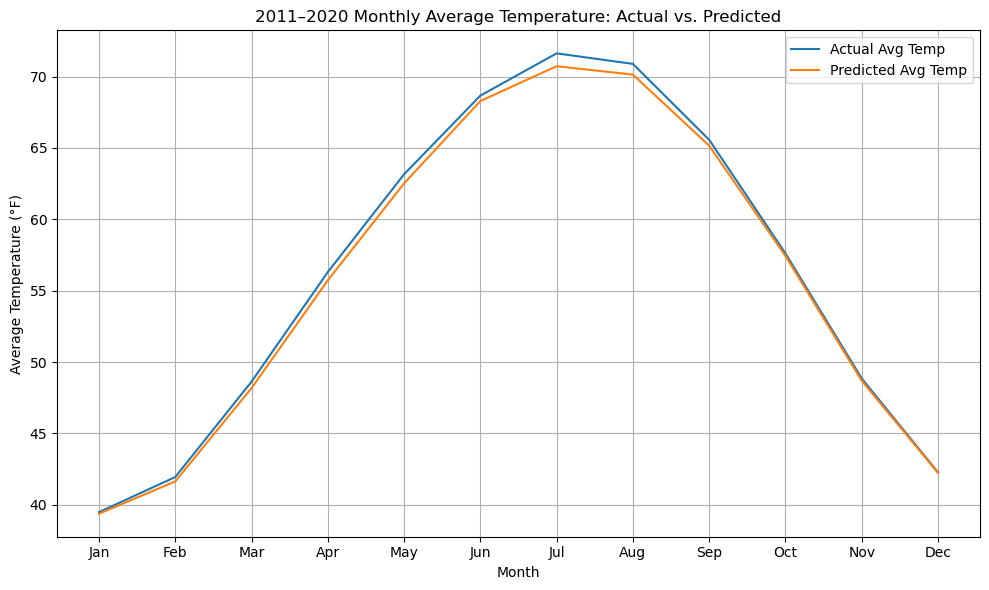

In [15]:
import matplotlib.pyplot as plt

monthly_pd = monthly_comparison.select(
    "month_name", "actual_avg_temp", "predicted_avg_temp"
).orderBy("month").toPandas()

plt.figure(figsize=(10, 6))
plt.plot(monthly_pd["month_name"], monthly_pd["actual_avg_temp"], label="Actual Avg Temp")
plt.plot(monthly_pd["month_name"], monthly_pd["predicted_avg_temp"], label="Predicted Avg Temp")
plt.title("2011–2020 Monthly Average Temperature: Actual vs. Predicted")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°F)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
